# Flood classification

Not every flood is made the same way. A spring flood fed by melting snow, a summer flash flood from
a single thunderstorm, and an autumn flood on ground that was already saturated are different
processes, and they respond differently to a warming climate. `xHydro` provides functions to sort
flood events into seven such classes, following the decision tree of
[Tramblay et al. (2025)](https://doi.org/10.5194/hess-29-7023-2025):

- `xh.indicators.split_streamflow` separates streamflow into baseflow and direct runoff.
- `xh.indicators.flood_types.soil_moisture_threshold` fits the soil wetness above which antecedent
  conditions count as "wet".
- `xh.indicators.flood_types.major_flood_events` gives the date of the largest flood of each
  period.
- `xh.indicators.flood_types.classify_flood_events` describes those events and sorts them into
  types.

This Notebook runs the whole chain on the distributed HBV-EC model built in the
[distributed Raven Notebook](hydrological_modelling_raven_distributed.ipynb), whose setup it reuses
verbatim up to the model configuration.

<div class="alert alert-warning"> <b>WARNING</b>

The meteorological data shipped with `xHydro`'s test suite covers **two years**. That is enough to
demonstrate the functions, and this Notebook is honest about where the record is too short to say
anything: a real flood-typology study needs several decades, since a single flood per year per
subbasin is the unit of analysis.

</div>

In [1]:
from IPython.display import clear_output

import xhydro as xh
import xhydro.modelling as xhm

clear_output(wait=False)

In [2]:
import logging

logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)

## Running the model

The watershed, the meteorological data and the 21 HBV-EC parameters are exactly those of the
[distributed Raven Notebook](hydrological_modelling_raven_distributed.ipynb) — refer to it for the
details of each step. Only the simulation period differs: we run the full extent of the available
forcing rather than a single year.

In [3]:
import tempfile
from pathlib import Path

import geopandas as gpd
import pooch
import xarray as xr

from xhydro.testing.helpers import (  # In-house function to get data from the xhydro-testdata repo
    deveraux,
)

notebook_folder = Path(tempfile.TemporaryDirectory().name)

# Watershed: 166 HRUs grouped into 47 subbasins.
hru = gpd.read_file(
    Path(
        deveraux().fetch(
            "ravenpy/hru_subset.zip",
            pooch.Unzip(),
        )[0]
    ).parents[0]
)
# As in the distributed Raven Notebook, revert to the default HBV-EC classes.
hru.loc[:, "LAND_USE_C"] = "LU_ALL"
hru.loc[:, "VEG_C"] = "VEG_ALL"
hru.loc[:, "SOIL_PROF"] = "DEFAULT_P"

# Meteorological data.
ds = xr.open_zarr(
    Path(
        deveraux().fetch(
            "pmp/CMIP.CCCma.CanESM5.historical.r1i1p1f1.day.gn.zarr.zip",
            pooch.Unzip(),
        )[0]
    ).parents[0]
)
ds_fx = xr.open_zarr(
    Path(
        deveraux().fetch(
            "pmp/CMIP.CCCma.CanESM5.historical.r1i1p1f1.fx.gn.zarr.zip",
            pooch.Unzip(),
        )[0]
    ).parents[0]
)
ds["orog"] = ds_fx["orog"]
ds = ds.drop_vars(["height"])
ds["pr"].attrs = {"units": "mm", "long_name": "precipitation"}
ds = ds[["pr", "tas", "orog"]]

ds_reformatted, config = xh.modelling.format_input(
    ds,
    "HBVEC",
    save_as=notebook_folder / "_data" / "meteo_flood_classification.nc",
)

/tmp/ipykernel_1111184/877512204.py:50: UserWarning: The calendar 'noleap' needs to be converted to 'standard', but 'convert_calendar_missing' is set to np.nan. NaNs will need to be filled manually before running HYDROTEL or Raven.


/home/antoinelefebvre-brossard/.miniconda3/envs/xhydro-dev/lib/python3.14/site-packages/clisops/utils/dataset_utils.py:1772: UserWarning: For coordinate variable 'longitude' no bounds can be identified.


Raven writes its streamflow to the hydrograph file, but the classification also needs rainfall,
snowmelt and soil water. Those are state variables and internal fluxes, which Raven only writes when
asked with a `:CustomOutput` command. We request them before the first run, so the model runs once:

- `RAINFALL` — the liquid fraction of precipitation.
- `SOIL[0]` — the water stored in the top soil layer.
- Four `Between:` fluxes carrying snowmelt. Each snow balance routes melt differently (HBV-EC sends
  it through `SNOW_LIQ` to `PONDED_WATER`, other balances go straight from `SNOW`), so requesting all
  four routes and summing them covers every configuration; the unused routes stay flat at zero.

In [4]:
# The 21 HBV-EC parameters, as in the distributed Raven Notebook.
parameters = [
    -0.15,
    3.5,
    3.0,
    0.07,
    0.4,
    0.8,
    1,
    4.0,
    0.5,
    0.1,
    1,
    5.0,
    4.8,
    0.1,
    1.0,
    22.0,
    0.5,
    0.1,
    0.0,
    1.0,
    1.0,
]

model_config = {
    "model_name": "HBVEC",
    "workdir": notebook_folder / "hbvec_flood_classification",
    "parameters": parameters,
    "global_parameter": {"AVG_ANNUAL_RUNOFF": 597},
    "hru": hru,
    "output_subbasins": "all",
    # The forcing starts on 2010-01-01 at noon and ends on 2011-12-31 at noon, so the
    # simulation has to sit strictly inside those bounds.
    "start_date": "2010-01-02",
    "end_date": "2011-12-30",
    "Evaporation": "PET_HARGREAVES",
    **config,
}

hm = xhm.hydrological_model(model_config)

In [5]:
hm.update_config(
    rvi_commands=[
        ":CustomOutput DAILY CUMULSUM RAINFALL BY_HRU",
        ":CustomOutput DAILY CUMULSUM SOIL[0] BY_HRU",
        ":CustomOutput DAILY CUMULSUM Between:SNOW.And.PONDED_WATER BY_HRU",
        ":CustomOutput DAILY CUMULSUM Between:SNOW_LIQ.And.PONDED_WATER BY_HRU",
        ":CustomOutput DAILY CUMULSUM Between:SNOW.And.SOIL[0] BY_HRU",
        ":CustomOutput DAILY CUMULSUM Between:SNOW_LIQ.And.SOIL[0] BY_HRU",
    ]
)

ds_out = hm.run()
ds_out

<xarray.Dataset> Size: 145kB
Dimensions:        (time: 728, subbasin_id: 47)
Coordinates:
  * time           (time) datetime64[ns] 6kB 2010-01-02 ... 2011-12-30
  * subbasin_id    (subbasin_id) <U2 376B '3' '4' '5' '6' ... '47' '48' '49'
    dowsub_id      (subbasin_id) <U2 376B ...
    station_id     (subbasin_id) <U6 1kB ...
    drainage_area  (subbasin_id) float64 376B ...
Data variables:
    q              (time, subbasin_id) float32 137kB ...
Attributes:
    Conventions:      CF-1.6
    featureType:      timeSeries
    history:          Created on 2026-08-18T14:24:16 by Raven 4.12
    description:      Standard Output
    references:       Craig J.R. and the Raven Development Team Raven user's ...
    model_id:         HBVEC
    Raven_version:    4.12
    RavenPy_version:  0.21.0

The custom outputs come out per HRU, while the streamflow is per subbasin. `aggregate_outputs`
accumulates the HRU values over everything upstream of each subbasin outlet, which is the footprint
the streamflow at that outlet integrates.

In [6]:
hm.aggregate_outputs(by="hru", to="drainage_area")

# These are small enough to hold in memory, and doing so keeps the rest of the
# Notebook free of Dask's restrictions on whole-array reductions.
rainfall = hm.get_outputs("RAINFALL*Drainage*").load()
soil = hm.get_outputs("SOIL[[]0[]]*Drainage*").load()
melt = hm.get_outputs("BETWEEN*Drainage*").load()

melt

/home/antoinelefebvre-brossard/documents/code/xhydro/src/xhydro/modelling/_ravenpy_models.py:732: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/home/antoinelefebvre-brossard/documents/code/xhydro/src/xhydro/modelling/_ravenpy_models.py:732: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/home/antoinelefebvre-brossard/documents/code/xhydro

<xarray.Dataset> Size: 1MB
Dimensions:                                     (time: 727, subbasin_id: 47)
Coordinates:
  * time                                        (time) datetime64[ns] 6kB 201...
  * subbasin_id                                 (subbasin_id) <U2 376B '3' .....
    dowsub_id                                   (subbasin_id) <U2 376B '-1' ....
    station_id                                  (subbasin_id) <U6 1kB '' ... ''
    drainage_area                               (subbasin_id) float64 376B 8....
Data variables:
    CumulSum_BETWEEN_SNOW_AND_SOIL[0]           (time, subbasin_id) float64 273kB ...
    CumulSum_BETWEEN_SNOW_LIQ_AND_PONDED_WATER  (time, subbasin_id) float64 273kB ...
    CumulSum_BETWEEN_SNOW_AND_PONDED_WATER      (time, subbasin_id) float64 273kB ...
    CumulSum_BETWEEN_SNOW_LIQ_AND_SOIL[0]       (time, subbasin_id) float64 273kB ...
Attributes:
    Conventions:      CF-1.6
    featureType:      timeSeries
    history:          Created on 2026-08-18T14:24:16 by Raven 4.12
    description:      Custom Output
    references:       Craig J.R. and the Raven Development Team Raven user's ...
    model_id:         HBVEC
    Raven_version:    4.12
    RavenPy_version:  0.21.0

## Building the inputs

The flood-type functions take five variables, and are strict about units: the fluxes (`mrro`, `prra`,
`snm`) must be convertible to `mm d-1`, and the stocks (`mrsol`, `mrsosat`) to `mm`. Three
conversions are needed to get there.

**Streamflow as a water depth.** `mrro` is the streamflow spread over the drainage area, so that
flow and rainfall share a unit and can be compared. `xHydro` already attaches `drainage_area` in km²
as a coordinate, and 1 m³ s⁻¹ over 1 km² for one day is 86.4 mm.

**Snowmelt from cumulative fluxes.** Raven's `Between:` fluxes accumulate since the start of the run,
so they must be differenced to recover a daily rate. `RAINFALL` and `SOIL[0]`, despite the
`CumulSum_` prefix they inherit from the command, are already daily values.

**A common time axis.** Differencing drops the first day, so every variable is aligned on the shorter
axis. The functions require all inputs to share `mrro`'s exact daily time coordinate.

In [7]:
melt_routes = [
    "CumulSum_BETWEEN_SNOW_AND_PONDED_WATER",
    "CumulSum_BETWEEN_SNOW_LIQ_AND_PONDED_WATER",
    "CumulSum_BETWEEN_SNOW_AND_SOIL[0]",
    "CumulSum_BETWEEN_SNOW_LIQ_AND_SOIL[0]",
]
snm = sum(melt[name].diff("time") for name in melt_routes)

# `diff` dropped the first day; align everything else on what is left.
time = snm.time

snm = snm.assign_attrs(units="mm d-1", long_name="Surface snow melt")
prra = rainfall["CumulSum_RAINFALL"].sel(time=time).assign_attrs(units="mm d-1", long_name="Rainfall")
mrsol = soil["CumulSum_SOIL[0]"].sel(time=time).assign_attrs(units="mm", long_name="Soil water content")
drainage_area = ds_out["drainage_area"]

# 1 m3 s-1 spread over 1 km2 for a day is 86.4 mm.
mrro = (ds_out["q"] * 86.4 / drainage_area).sel(time=time)
mrro.attrs = {"units": "mm d-1", "long_name": "River discharge"}

xr.Dataset({"mrro": mrro, "prra": prra, "snm": snm, "mrsol": mrsol})

<xarray.Dataset> Size: 1MB
Dimensions:        (time: 726, subbasin_id: 47)
Coordinates:
  * time           (time) datetime64[ns] 6kB 2010-01-04 ... 2011-12-30
  * subbasin_id    (subbasin_id) <U2 376B '3' '4' '5' '6' ... '47' '48' '49'
    dowsub_id      (subbasin_id) <U2 376B '-1' '3' '4' '5' ... '46' '46' '48'
    station_id     (subbasin_id) <U6 1kB '' '' '' '' '' '' ... '' '' '' '' '' ''
    drainage_area  (subbasin_id) float64 376B 8.182e+04 8.179e+04 ... 255.7
Data variables:
    mrro           (time, subbasin_id) float64 273kB 2.782e-06 0.0 ... 0.002855
    prra           (time, subbasin_id) float64 273kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    snm            (time, subbasin_id) float64 273kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    mrsol          (time, subbasin_id) float64 273kB 4.399 4.298 ... 200.0 200.0

### Soil water at saturation

The classification does not use the soil water content directly, but the **soil wetness index** —
the water in the top soil layer divided by what that layer holds when saturated. The functions do
that division for us if we hand them the capacity as `mrsosat`.

For an HBV-EC model, that capacity is the porosity of the top soil class times the thickness of the
first layer of the soil profile. Both are written in the `.rvp` file Raven ran with, so we read them
from there rather than reproducing the parameter list by hand.

In [8]:
def read_topsoil_capacity(path):
    """Return the water the top soil layer holds at saturation (mm), read from a Raven .rvp file."""

    def section(lines, name):
        stripped = [line.strip() for line in lines]
        body = stripped[stripped.index(f":{name}") + 1 : stripped.index(f":End{name}")]
        # ':' lines are the column headers, '#' lines are comments
        return [line for line in body if line and not line.startswith((":", "#"))]

    lines = path.read_text().splitlines()

    # A soil profile reads "name, n_layers, class_1, thickness_1, class_2, ...";
    # SOIL[0] is the first layer, and its thickness is in metres.
    profile = [field.strip() for field in section(lines, "SoilProfiles")[0].split(",")]
    soil_class, thickness = profile[2], float(profile[3])

    # POROSITY is the first column of the soil parameter list. A class that does
    # not set it inherits the '[DEFAULT]' row.
    porosity = {}
    for row in section(lines, "SoilParameterList"):
        fields = [field.strip() for field in row.split(",")]
        porosity[fields[0]] = fields[1]
    value = porosity[soil_class]
    if value == "_DEFAULT":
        value = porosity["[DEFAULT]"]

    return float(value) * thickness * 1000


mrsosat = xr.DataArray(
    read_topsoil_capacity(hm.workdir / f"{hm.run_name}.rvp"),
    attrs={"units": "mm", "long_name": "Soil moisture content at saturation"},
)

# For this configuration the capacity is the POROSITY (X05) and topsoil thickness (X17) parameters.
assert float(mrsosat) == parameters[4] * parameters[16] * 1000
mrsosat

<xarray.DataArray ()> Size: 8B
array(200.)
Attributes:
    units:      mm
    long_name:  Soil moisture content at saturation

<div class="alert alert-info"> <b>INFO</b>

The Notebook forces a single soil profile on every HRU, so the capacity is one number for the whole
watershed. A model with several soil profiles has a different capacity per HRU, which must be
aggregated to the drainage area the same way the other variables were.

If your model does not expose its storage capacity at all, you can instead normalise the soil water
yourself — for instance by its own long-term range — and pass the result as a dimensionless `mrsol`
in [0, 1], leaving `mrsosat` as `None`. The fitted threshold absorbs a positive rescaling of the
index, so the classification is unchanged.

</div>

## Separating baseflow from direct runoff

A flood is the direct-runoff part of the hydrograph riding on top of the slower baseflow.
`split_streamflow` separates the two with the Lyne-Hollick recursive digital filter, alternating
forward and backward passes over the series.

This matters for the classification because one of the event descriptors,
`direct_streamflow_fraction`, is the share of the peak-day flow that is direct runoff.
`classify_flood_events` computes it from this filter unless you supply your own surface runoff.

In [9]:
baseflow, runoff = xh.indicators.split_streamflow(ds_out["q"])
baseflow

<xarray.DataArray 'q_base' (time: 728, subbasin_id: 47)> Size: 137kB
array([[1.2128477e+00, 1.2008829e+00, 1.1842413e+00, ..., 9.7505569e-02,
        9.5054984e-02, 5.3102747e-03],
       [3.1183004e-01, 3.0785561e-01, 3.0356598e-01, ..., 2.4928987e-02,
        2.4304509e-02, 1.3577938e-03],
       [2.6345744e-03, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [2.1807814e+00, 2.1585872e+00, 2.1244643e+00, ..., 1.4937381e-01,
        1.5039656e-01, 8.5912198e-03],
       [2.1536498e+00, 2.1317315e+00, 2.0980334e+00, ..., 1.4751543e-01,
        1.4852543e-01, 8.4843347e-03],
       [2.1447134e+00, 2.1228862e+00, 2.0893278e+00, ..., 1.4690334e-01,
        1.4790915e-01, 8.4491298e-03]], shape=(728, 47), dtype=float32)
Coordinates:
  * time           (time) datetime64[ns] 6kB 2010-01-02 ... 2011-12-30
  * subbasin_id    (subbasin_id) <U2 376B '3' '4' '5' '6' ... '47' '48' '49'
    dowsub_id      (subbasin_id) <U2 376B ...
    station_id     (subbasin_id) <U6 1kB ...
    drainage_area  (subbasin_id) float64 376B ...
Attributes:
    units:              m3 s-1
    long_name:          Baseflow
    description:        Baseflow component of the streamflow, separated with ...
    cell_methods:       time: mean
    aggregation_level:  DrainageArea

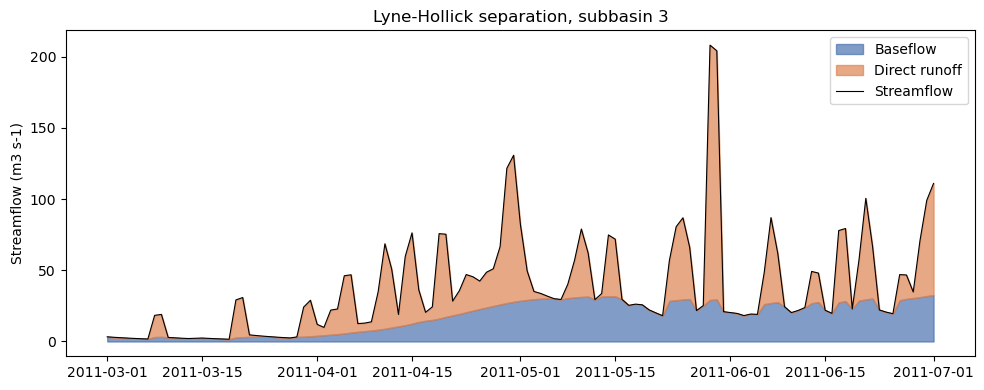

In [10]:
import matplotlib.pyplot as plt

subbasin = str(ds_out.subbasin_id[0].item())
period = slice("2011-03-01", "2011-07-01")

fig, ax = plt.subplots(figsize=(10, 4))
total = ds_out["q"].sel(subbasin_id=subbasin, time=period)
base = baseflow.sel(subbasin_id=subbasin, time=period)

ax.fill_between(total.time, 0, base, label="Baseflow", color="#4c72b0", alpha=0.7)
ax.fill_between(total.time, base, total, label="Direct runoff", color="#dd8452", alpha=0.7)
ax.plot(total.time, total, color="black", linewidth=0.8, label="Streamflow")
ax.set_ylabel(f"Streamflow ({ds_out['q'].attrs['units']})")
ax.set_title(f"Lyne-Hollick separation, subbasin {subbasin}")
ax.legend()
plt.tight_layout()

## The soil moisture threshold

Two of the seven flood types describe floods on ground that was already wet. Deciding what "wet"
means is not a fixed number: it is the soil wetness above which floods stop growing with antecedent
wetness, and it differs from one subbasin to the next.

`soil_moisture_threshold` fits it over a reference period, following
[Tramblay et al. (2022)](https://doi.org/10.1038/s41598-022-23725-5). It keeps every day whose flow
exceeds the 10th percentile, declusters them into independent events, and — if at least 10 events
survive and antecedent wetness correlates with peak flow — fits an exponential curve and takes the
changepoint of that curve as the threshold. When either gate fails, it returns `inf`, which simply
disables the two soil-water-excess types.

In [11]:
threshold = xh.indicators.flood_types.soil_moisture_threshold(
    mrro=mrro,
    prra=prra,
    mrsol=mrsol,
    mrsosat=mrsosat,
    drainage_area=drainage_area,
    # The whole record; a shorter reference period would be mostly warm-up.
    period=["2010", "2011"],
)
threshold

<xarray.DataArray 'swi_threshold' (subbasin_id: 47)> Size: 376B
array([       inf,        inf,        inf,        inf, 0.94905659,
              inf,        inf, 0.94920643,        inf,        inf,
              inf,        inf,        inf,        inf, 0.94705237,
              inf, 0.94641319,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf,        inf,        inf,        inf,
              inf,        inf])
Coordinates:
  * subbasin_id    (subbasin_id) <U2 376B '3' '4' '5' '6' ... '47' '48' '49'
    dowsub_id      (subbasin_id) <U2 376B '-1' '3' '4' '5' ... '46' '46' '48'
    station_id     (subbasin_id) <U6 1kB '' '' '' '' '' '' ... '' '' '' '' '' ''
    drainage_area  (subbasin_id) float64 376B 8.182e+04 8.179e+04 ... 255.7
Attributes:
    units:        1
    long_name:    Soil moisture threshold
    description:  Changepoint of the exponential fit of reference-period peak...

Four subbasins out of 47 get a finite threshold; the rest come back as `inf`, and the reason is worth
seeing rather than treating as a failure. The gate that fails is the correlation, not the event
count: declustering leaves comfortably more than the minimum of 10 events. Plotting the soil wetness
shows what happened.

Median soil wetness: 1.000
Share of the record above 0.99: 80.6%


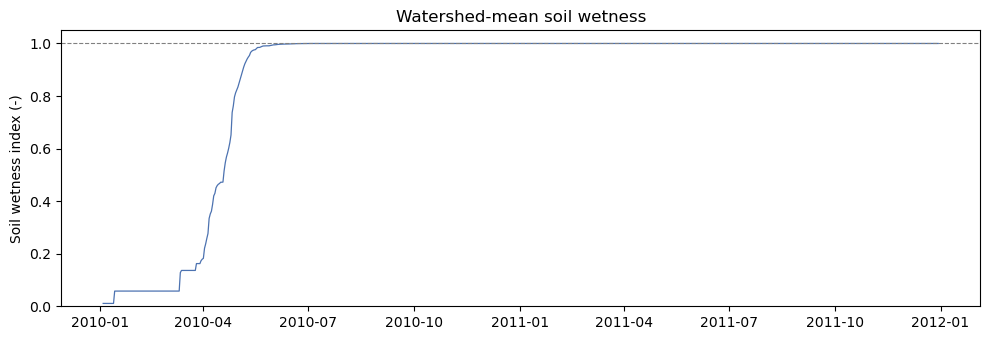

In [12]:
swi = (mrsol / mrsosat).rename("swi")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(swi.time, swi.mean("subbasin_id"), color="#4c72b0", linewidth=0.9)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Soil wetness index (-)")
ax.set_title("Watershed-mean soil wetness")
plt.tight_layout()

saturated = float((swi > 0.99).mean())
print(f"Median soil wetness: {float(swi.median()):.3f}")
print(f"Share of the record above 0.99: {saturated:.1%}")

Two things are visible, and both are about the record being short.

The soil store starts **empty** and takes roughly five months to fill: that is the model warming up,
not hydrology. A study would discard those months — the reference analysis this Notebook follows
drops three years of warm-up — but with a two-year record there is nothing left to drop.

After it fills, the wetness sits pinned at saturation. A variable with almost no variance cannot
correlate with peak flow, so the fit correctly declines to produce a threshold nearly everywhere. A longer, better-spun-up
simulation of a less permanently saturated watershed is what this function expects.

## Extracting the flood events

`major_flood_events` returns the date of the largest flood of each period, and nothing else.
Describing that flood is the next function's job, which keeps the two questions apart: locating the
peak only needs streamflow.

The `freq` argument sets the periods. The default `"YS-DEC"` runs years from 1 December to
30 November, so a winter is never split across two years. With two years of data that gives only
three events per subbasin — enough to show what the function returns, not enough to analyse.

In [13]:
annual = xh.indicators.flood_types.major_flood_events(mrro=mrro)
annual

<xarray.DataArray 'event_date' (time: 3, subbasin_id: 47)> Size: 1kB
array([['2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
        '2010-06-29T00:00:00.000000000', '2010-06-29T00:00:00.000000000',
...
        '2011-12-06T00:00:00.000000000', '2011-12-06T00:00:00.000000000',
        '2011-12-07T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-07T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-06T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-06T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-07T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-07T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000']], dtype='datetime64[ns]')
Coordinates:
  * time           (time) datetime64[ns] 24B 2009-12-01 2010-12-01 2011-12-01
  * subbasin_id    (subbasin_id) <U2 376B '3' '4' '5' '6' ... '47' '48' '49'
    dowsub_id      (subbasin_id) <U2 376B '-1' '3' '4' '5' ... '46' '46' '48'
    station_id     (subbasin_id) <U6 1kB '' '' '' '' '' '' ... '' '' '' '' '' ''
    drainage_area  (subbasin_id) float64 376B 8.182e+04 8.179e+04 ... 255.7
Attributes:
    long_name:    Date of the major flood event
    description:  Date of the period's maximum streamflow; NaT where the peri...

Switching to `"QS-DEC"` gives one event per season instead, which is what the rest of this Notebook
uses: nine periods across 47 subbasins is enough to draw a map. The first and last periods are
truncated by the ends of the record, so their peak is drawn from a partial window.

In [14]:
seasonal = xh.indicators.flood_types.major_flood_events(mrro=mrro, freq="QS-DEC")
seasonal

<xarray.DataArray 'event_date' (time: 9, subbasin_id: 47)> Size: 3kB
array([['2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
        '2010-01-04T00:00:00.000000000', '2010-01-04T00:00:00.000000000',
...
        '2011-12-06T00:00:00.000000000', '2011-12-06T00:00:00.000000000',
        '2011-12-07T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-07T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-06T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-06T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-07T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-07T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-07T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000', '2011-12-09T00:00:00.000000000',
        '2011-12-09T00:00:00.000000000']], dtype='datetime64[ns]')
Coordinates:
  * time           (time) datetime64[ns] 72B 2009-12-01 ... 2011-12-01
  * subbasin_id    (subbasin_id) <U2 376B '3' '4' '5' '6' ... '47' '48' '49'
    dowsub_id      (subbasin_id) <U2 376B '-1' '3' '4' '5' ... '46' '46' '48'
    station_id     (subbasin_id) <U6 1kB '' '' '' '' '' '' ... '' '' '' '' '' ''
    drainage_area  (subbasin_id) float64 376B 8.182e+04 8.179e+04 ... 255.7
Attributes:
    long_name:    Date of the major flood event
    description:  Date of the period's maximum streamflow; NaT where the peri...

## Describing and classifying the events

`classify_flood_events` builds an event around each date — the peak day plus the run of rainy days
directly before it, up to seven days in total — and summarizes rainfall, snowmelt and antecedent
wetness over that window. It then walks a decision tree over those descriptors, in order. Let `S` be
the event's total snowmelt and `R` its total rainfall:

| # | Type | Criterion |
|---|---|---|
| 0 | snowmelt | `S > 4 R` |
| 1 | mostly snowmelt with some rainfall | `S > 2 R` |
| 2 | rain-on-snow | `S > 0.25 R` |
| 3 | soil water excess and short rain | wet soil, and one day carried more than 75 % of the rain |
| 4 | soil water excess and long rain | wet soil |
| 5 | short rain | one day carried more than 75 % of the rain |
| 6 | long rain | otherwise |

"Wet soil" means the antecedent wetness exceeded the threshold. The returned Dataset carries the
descriptors and the type as `flood_type`, an integer code; the names live in its `flag_meanings`
attribute, so read them from there rather than writing them out.

A single date works in place of the whole array, which is how you classify one flood you picked
yourself.

In [15]:
events = xh.indicators.flood_types.classify_flood_events(
    seasonal,
    mrro=mrro,
    prra=prra,
    snm=snm,
    mrsol=mrsol,
    mrsosat=mrsosat,
    threshold=threshold,
)
events

/home/antoinelefebvre-brossard/documents/code/xhydro/src/xhydro/indicators/flood_types.py:614: RuntimeWarning: invalid value encountered in scalar divide


<xarray.Dataset> Size: 30kB
Dimensions:                     (subbasin_id: 47, time: 9)
Coordinates:
  * subbasin_id                 (subbasin_id) <U2 376B '3' '4' '5' ... '48' '49'
    dowsub_id                   (subbasin_id) <U2 376B '-1' '3' ... '46' '48'
    station_id                  (subbasin_id) <U6 1kB '' '' '' '' ... '' '' ''
    drainage_area               (subbasin_id) float64 376B 8.182e+04 ... 255.7
  * time                        (time) datetime64[ns] 72B 2009-12-01 ... 2011...
Data variables:
    mrro_peak                   (time, subbasin_id) float64 3kB 2.782e-06 ......
    mrro_peak_doy               (time, subbasin_id) float64 3kB 4.0 ... 343.0
    event_duration              (time, subbasin_id) float64 3kB 1.0 1.0 ... 2.0
    prra_sum                    (time, subbasin_id) float64 3kB 0.0 0.0 ... 10.2
    prra_max                    (time, subbasin_id) float64 3kB 0.0 0.0 ... 10.2
    snm_sum                     (time, subbasin_id) float64 3kB 0.0 ... 2.058
    swi_antecedent              (time, subbasin_id) float64 3kB nan nan ... 1.0
    direct_streamflow_fraction  (time, subbasin_id) float64 3kB 0.0 ... 0.8577
    flood_type                  (time, subbasin_id) int16 846B 6 6 6 6 ... 5 5 5

Here is one such event: the spring 2011 flood in the first subbasin, with its window shaded and the
rainfall that defined it.

`classify_flood_events` also takes a single date in place of the whole array, which is how you
describe one flood you picked yourself. It returns the same descriptors, on a Dataset with no time
axis.

In [16]:
# `seasonal` holds one date per season and per subbasin, so selecting both gives a single date.
date = seasonal.sel(subbasin_id=subbasin).isel(time=5)

event = xh.indicators.flood_types.classify_flood_events(
    date,
    mrro=mrro.sel(subbasin_id=subbasin),
    prra=prra.sel(subbasin_id=subbasin),
    snm=snm.sel(subbasin_id=subbasin),
    mrsol=mrsol.sel(subbasin_id=subbasin),
    mrsosat=mrsosat,
    threshold=threshold.sel(subbasin_id=subbasin),
)
event

<xarray.Dataset> Size: 122B
Dimensions:                     ()
Coordinates:
    subbasin_id                 <U2 8B '3'
    dowsub_id                   <U2 8B '-1'
    station_id                  <U6 24B ''
    drainage_area               float64 8B 8.182e+04
    time                        datetime64[ns] 8B 2011-05-29
Data variables:
    mrro_peak                   float64 8B 0.2197
    mrro_peak_doy               float64 8B 149.0
    event_duration              float64 8B 2.0
    prra_sum                    float64 8B 50.83
    prra_max                    float64 8B 45.09
    snm_sum                     float64 8B 0.0
    swi_antecedent              float64 8B 1.0
    direct_streamflow_fraction  float64 8B 0.8598
    flood_type                  int16 2B 5

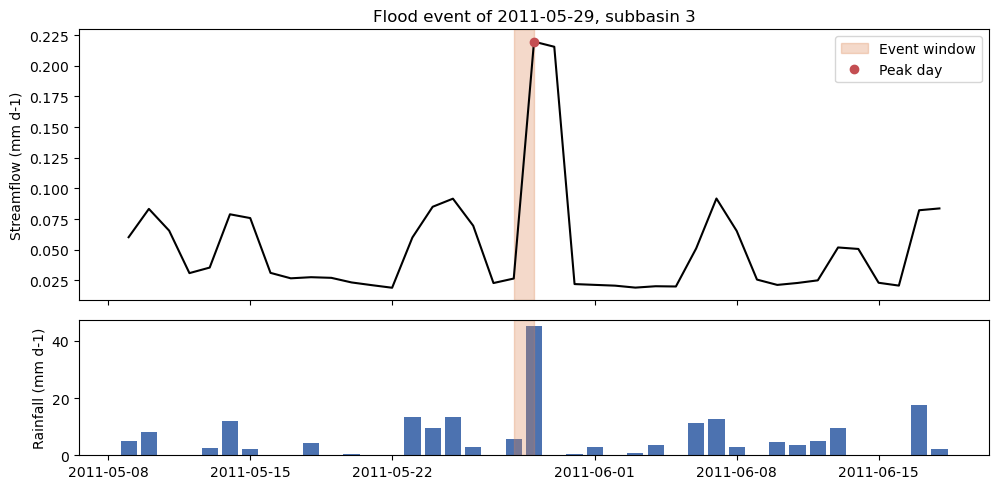

In [17]:
import numpy as np
import pandas as pd

peak = pd.Timestamp(date.values)
start = peak - pd.Timedelta(days=int(event["event_duration"]) - 1)
window = slice(peak - pd.Timedelta(days=20), peak + pd.Timedelta(days=20))

fig, (ax, ax_rain) = plt.subplots(2, 1, figsize=(10, 5), sharex=True, height_ratios=[2, 1])
ax.plot(mrro.sel(subbasin_id=subbasin, time=window).time, mrro.sel(subbasin_id=subbasin, time=window), color="black")
ax.axvspan(start, peak, color="#dd8452", alpha=0.3, label="Event window")
ax.plot([peak], [float(event["mrro_peak"])], "o", color="#c44e52", label="Peak day")
ax.set_ylabel("Streamflow (mm d-1)")
ax.legend()
ax.set_title(f"Flood event of {peak.date()}, subbasin {subbasin}")

ax_rain.bar(prra.sel(subbasin_id=subbasin, time=window).time, prra.sel(subbasin_id=subbasin, time=window), color="#4c72b0")
ax_rain.axvspan(start, peak, color="#dd8452", alpha=0.3)
ax_rain.set_ylabel("Rainfall (mm d-1)")
plt.tight_layout()

In [18]:
flood_type = events["flood_type"]
names = flood_type.attrs["flag_meanings"].split()

counts = pd.Series(
    {name: int((flood_type == code).sum()) for code, name in enumerate(names)},
    name="events",
)
counts

snowmelt                                0
mostly_snowmelt_with_some_rainfall      0
rain_on_snow                           18
soil_water_excess_and_short_rain       12
soil_water_excess_and_long_rain        16
short_rain                             82
long_rain                             295
Name: events, dtype: int64

Five of the seven types appear. The two snowmelt types are absent because this model's seasonal peak
flows are driven by rain even in spring, and the two soil-water-excess types are confined to the four
subbasins whose threshold came back finite.

`threshold` is an ordinary argument, so you can pass a value of your own to see what those two types
would capture across the whole watershed. Below, "wet" is taken to be any wetness above the median.

In [19]:
explicit = xh.indicators.flood_types.classify_flood_events(
    seasonal,
    mrro=mrro,
    prra=prra,
    snm=snm,
    mrsol=mrsol,
    mrsosat=mrsosat,
    threshold=float(events["swi_antecedent"].median()),
)["flood_type"]

pd.DataFrame(
    {
        "fitted threshold": counts,
        "median wetness": [int((explicit == code).sum()) for code in range(len(names))],
    }
)

/home/antoinelefebvre-brossard/documents/code/xhydro/src/xhydro/indicators/flood_types.py:614: RuntimeWarning: invalid value encountered in scalar divide


,fitted threshold,median wetness
snowmelt,0,0
mostly_snowmelt_with_some_rainfall,0,0
rain_on_snow,18,18
soil_water_excess_and_short_rain,12,53
soil_water_excess_and_long_rain,16,116
short_rain,82,41
long_rain,295,195


## Where each type dominates

The point of classifying floods per subbasin is to see the spatial pattern: which parts of the
watershed flood from snow, which from storms, which from saturated ground. The map below gives, for
each type, the share of a subbasin's events that fall in it.

In [20]:
# Subbasin geometries, dissolved from the HRUs the model ran on.
subbasins = hru.dissolve(by="SubId")[["geometry"]]
subbasins.index = subbasins.index.astype(str)

# Share of each subbasin's events per type. Reindexing over every type keeps the
# empty ones in the figure instead of silently dropping their panel.
proportions = (
    xr.concat([(flood_type == code).mean("time") for code in range(len(names))], dim="flood_type")
    .assign_coords(flood_type=names)
    .to_pandas()
)
proportions

subbasin_id,3,4,5,6,7,8,9,10,11,12,...,40,41,42,43,44,45,46,47,48,49
flood_type,,,,,,,,,,,,,,,,,,,,,
snowmelt,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
mostly_snowmelt_with_some_rainfall,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
rain_on_snow,0.111111,0.111111,0.111111,0.111111,0.000000,0.111111,0.111111,0.000000,0.111111,0.111111,...,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
soil_water_excess_and_short_rain,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.333333,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
soil_water_excess_and_long_rain,0.000000,0.000000,0.000000,0.000000,0.444444,0.000000,0.000000,0.444444,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
short_rain,0.222222,0.222222,0.222222,0.222222,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,...,0.222222,0.222222,0.333333,0.111111,0.333333,0.222222,0.222222,0.222222,0.333333,0.222222
long_rain,0.666667,0.666667,0.666667,0.666667,0.111111,0.777778,0.777778,0.111111,0.777778,0.777778,...,0.777778,0.777778,0.666667,0.777778,0.666667,0.777778,0.777778,0.777778,0.666667,0.777778


Text(0.5, 0.98, 'Proportion of flood events by type')

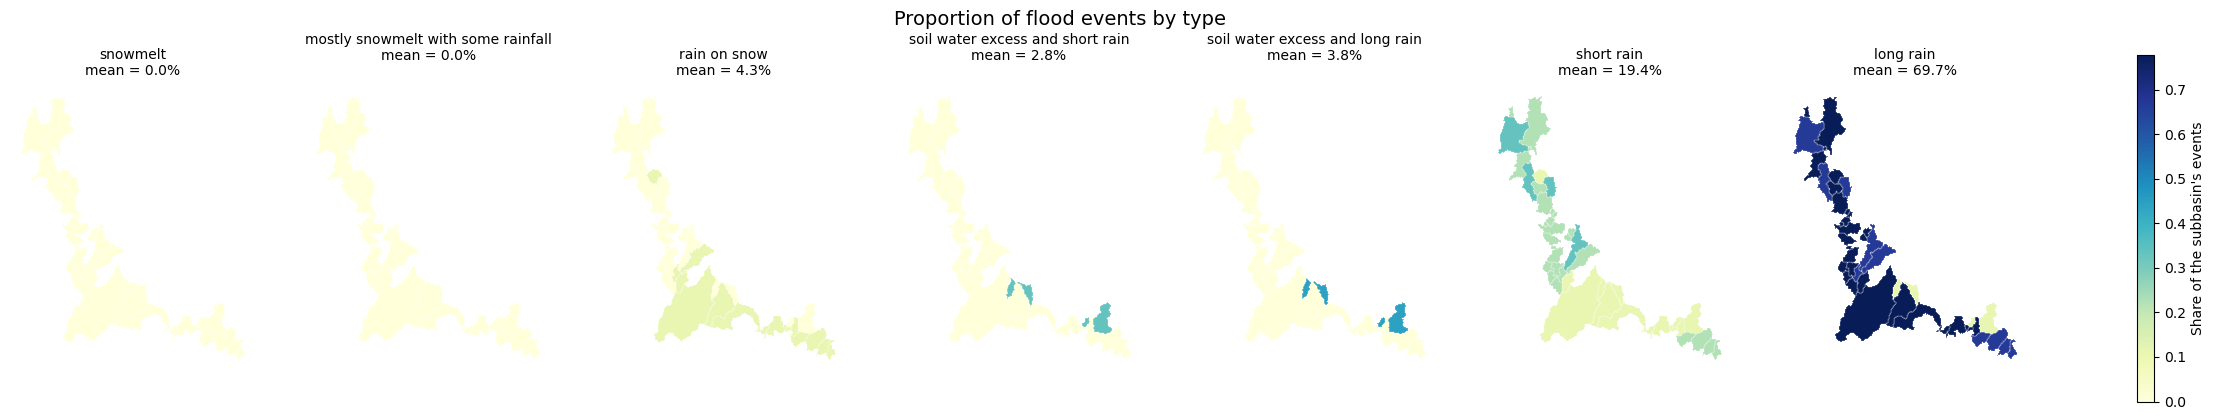

In [21]:
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4.5))
vmax = float(proportions.to_numpy().max())

for ax, name in zip(axes, names):
    panel = subbasins.join(proportions.loc[name].rename("proportion"))
    panel.plot(column="proportion", ax=ax, cmap="YlGnBu", vmin=0, vmax=vmax, edgecolor="white", linewidth=0.2)
    ax.set_title(f"{name.replace('_', ' ')}\nmean = {panel['proportion'].mean():.1%}", fontsize=10)
    ax.set_axis_off()

fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(0, vmax), cmap="YlGnBu"),
    ax=axes,
    label="Share of the subbasin's events",
    fraction=0.02,
)
fig.suptitle("Proportion of flood events by type", fontsize=14)

The same idea applied to the descriptors rather than the types: the average conditions under which
each subbasin floods. Each panel carries its own colour scale, since the units differ.

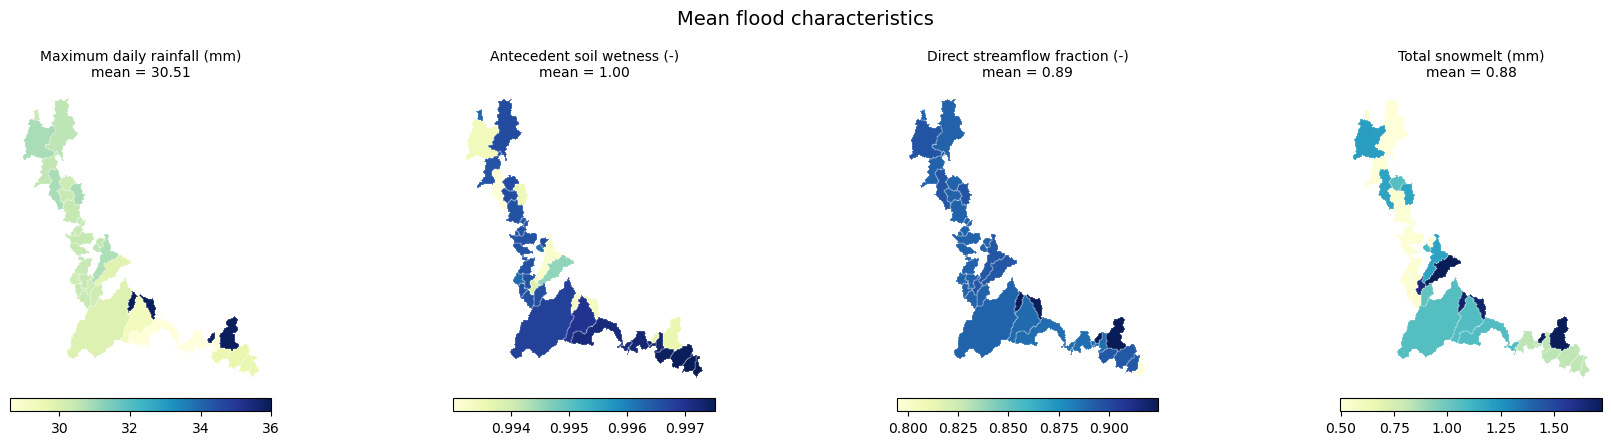

In [22]:
characteristics = {
    "prra_max": "Maximum daily rainfall (mm)",
    "swi_antecedent": "Antecedent soil wetness (-)",
    "direct_streamflow_fraction": "Direct streamflow fraction (-)",
    "snm_sum": "Total snowmelt (mm)",
}

fig, axes = plt.subplots(1, len(characteristics), figsize=(4.5 * len(characteristics), 4.5))

for ax, (variable, label) in zip(axes, characteristics.items()):
    values = events[variable].mean("time").to_pandas().rename("value")
    panel = subbasins.join(values)
    panel.plot(
        column="value",
        ax=ax,
        cmap="YlGnBu",
        edgecolor="white",
        linewidth=0.2,
        legend=True,
        legend_kwds={"orientation": "horizontal", "fraction": 0.04, "pad": 0.02},
    )
    ax.set_title(f"{label}\nmean = {panel['value'].mean():.2f}", fontsize=10)
    ax.set_axis_off()

fig.suptitle("Mean flood characteristics", fontsize=14)
plt.tight_layout()

## Going further

The natural next step, and the reason these classes are computed at all, is to ask how their
frequency changes over time: run the same chain on a multi-decadal climate projection, take one flood
per year, and test the trend in each type's frequency. That analysis needs decades of data and
trend statistics that `xHydro` does not provide, so it is left out of this Notebook.

## References

- Lyne, V. D. and Hollick, M. (1979). Stochastic time-variable rainfall runoff modelling.
  *Hydrology and Water Resources Symposium*, Institute of Engineers Australia, 89-93.
- Tramblay, Y., Villarini, G., Saidi, M. E., Massari, C., & Stein, L. (2022). Classification of
  flood-generating processes in Africa. *Scientific Reports*, 12, 18920.
  https://doi.org/10.1038/s41598-022-23725-5
- Tramblay, Y., Thirel, G., Strohmenger, L., Evin, G., Corre, L., Heraut, L., & Sauquet, E. (2025).
  Evolution of flood generating processes under climate change in France. *Hydrology and Earth
  System Sciences*, 29, 7023-7039. https://doi.org/10.5194/hess-29-7023-2025